# **Nettoyage des données et statistiques descriptives**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### **0. Importation des données**

In [1]:
!pip install pyreadstat
import s3fs
import pandas as pd
import tempfile
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "gbern13"

FILE_PATH_S3 = f"{MY_BUCKET}/diffusion/PISA2022/student_questionnaire/CY08MSP_STU_QQQ.SAV"
with fs.open(FILE_PATH_S3, "rb") as s3f:
    with tempfile.NamedTemporaryFile(suffix=".sav") as tmp:
        tmp.write(s3f.read())
        tmp.flush()
        df = pd.read_spss(tmp.name)

print(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.2 MB/s  0:00:00
       CNT  CNTRYID  CNTSCHID  CNTSTUID   CYC   NatCen  \
0  Albania  Albania  800282.0  800001.0  08MS  Albania   
1  Albania  Albania  800115.0  800002.0  08MS  Albania   
2  Albania  Albania  800242.0  800003.0  08MS  Albania   
3  Albania  Albania  800245.0  800005.0  08MS  Albania   
4  Albania  Albania  800285.0  800006.0  08MS  Albania   

                                     STRATUM SUBNATIO   REGION OECD  ...  \
0  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   
1  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   
2   ALB - stratum 01: Urban / North / Public  Albania  Albania   No  ...   
3  ALB - stratum 08: Rural / Center / Public  Albania  Albania   No  ...   
4  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   

   PV3MPRE  PV4MPRE  PV5MPRE  PV6MPRE  PV7MPRE  PV8MPRE  PV9MPRE PV10MPRE  \
0  226.250  203.029  219.817  331.017  223.

Le dataset contient plus de 1200 variables et plus de 600 000 observations. 
Pour alléger le jeu de données et faciliter l'analyse qui sera menée au cours du projet il est nécessaire de nettoyer le jeu de données. 


### **I. Nettoyage du dataset et preprocessing**

L'objectif de cette première partie est d'obtenir un jeu de données propre qui permettra ensuite de se familiariser avec les données au travers d'une analyse descriptive et enfin d'effectuer une première modélisation qui tentera de répondre à la problématique. 

#### 1. **Premier choix des variables**

Le dataset importé contient plus de 1200 variables. La majorité de ces variables sont issues directement des questionnaires adressés aux étudiants. Pour un même facteur explicatif de la créativité d'un élève, on peut associer plusieurs questions qui permettent dy répondre. Il faudrait alors créer pour chaque facteur créer une variable synthétique à partir des variables disponibles dans le dataset. Ces variables synthétiques dérivées sont également disponibles dans le dataset et sont au nombre de 86. 

Cette partie présente l'ensemble des variables choisies pour répondre au mieux à la problématique du sujet. 

In [15]:
## Liste contenant les variables choisies 
variables=['CNTSTUID','ST004D01T','ESCS','LANGN','EXERPRAC','WORKPAY','WORKHOME','ICTRES','BULLIED',
'SCHRISK','FAMSUP','TEACHSUP','PARINVOL','SCHSUST','CREATOOS','CREATAS','EXPO21ST','FEELSAFE']
## Réduction du dataset à ces variables 
data=df[variables].copy()
## Nouveaux noms des variables 
renom=['id','gender','society','home_language','sport','work','household_care','digital_home',
'social','school_safety','family_support','teacher_support','parent_invol','school_support','creative_out',
'creative_at','math_reasoning','safety']
## Renommage des variables
data.columns=renom
data.head()


,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety
0,800001.0,Female,1.1112,Albanian,No exercise or sports,No work for pay,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246
1,800002.0,Male,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246
2,800003.0,Male,-0.1867,Albanian,NaN,No work for pay,No work in household or care of family members,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8637
3,800005.0,Female,-3.2198,Albanian,10 or more times of exercising or sports per week,No work for pay,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,-0.7468,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560
4,800006.0,Female,-1.0548,Albanian,2 times of exercising or sports per week,No work for pay,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246


Justification du choix des variables : 
Parmi l'ensemble des variables synthétiques disponibles, plusieurs variables différentes peuvent être utilisées comme variable explicative. Néanmoins, certaines d'entre elles ne sont pas adaptées en raison d'une distribution qui ne contient pas assez d'informations par exemple. 

Comparons par exemple les variables **ICTRES** ('nouveau nom de la variable') et **ICTHOME**

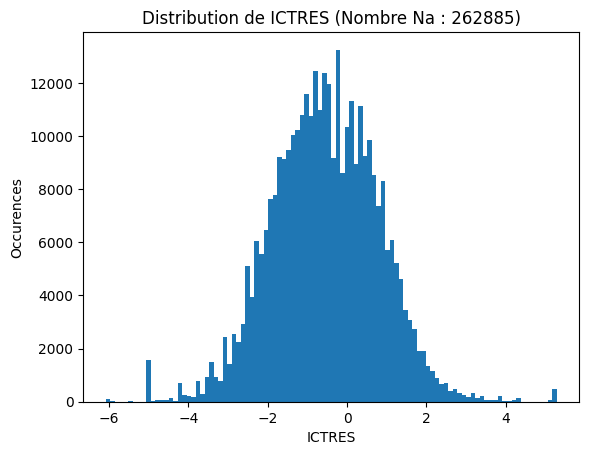

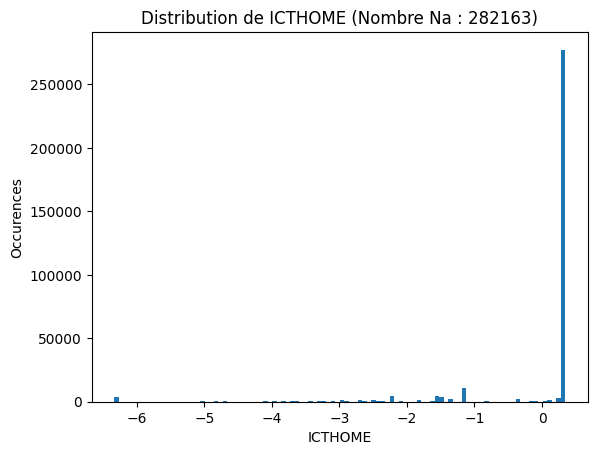

In [23]:
ictres,icthome=df['ICTRES'],df['ICTHOME']
ictres_na,icthome_na=ictres.isna().sum(),icthome.isna().sum()
# Distribution ICTRES
plt.hist(ictres,bins=100)
plt.xlabel('ICTRES')
plt.ylabel('Occurences')
plt.title('Distribution de ICTRES '+f'(Nombre Na : {ictres_na})')
plt.show()
# Distribution ICTHOME 
plt.hist(icthome,bins=100)
plt.xlabel('ICTHOME')
plt.ylabel('Occurences')
plt.title('Distribution de ICTHOME '+f'(Nombre Na : {icthome_na})')
plt.show()

In [25]:
# Nombre d'occurence des valeurs prises par ces deux variables 
ictres_count=ictres.value_counts()
icthome_count=icthome.value_counts()
ictres_count,icthome_count

(ICTRES
 -0.2035    2866
 -0.4979    2436
 -0.5542    1990
 -0.8053    1916
  0.1083    1429
            ... 
  4.2096       1
  4.2365       1
  4.2450       1
  4.2846       1
  4.3014       1
 Name: count, Length: 40459, dtype: int64,
 ICTHOME
  0.3346    274384
 -1.1402     11095
 -1.5118      3886
 -6.3292      3830
 -2.2168      2933
             ...  
 -4.4253         1
 -4.4221         1
 -4.4062         1
 -1.4106         1
 -6.2014         1
 Name: count, Length: 488, dtype: int64)

In [48]:
# Nombre de valeurs de ICTHOME qui apparaissent au moins 2900 fois
len(icthome_count[icthome_count>=2900])

5

In [50]:
# Part d'observations dont la valeur ICTHOME prend une des 5 valeurs les plus présente
p=round(icthome_count[icthome_count>=2900].sum()/icthome_count.sum()*100,2)
print(f'5 valeurs de la variables ICTHOME sont prises par {p} % des observations du dataset.')

5 valeurs de la variables ICTHOME sont prises par 89.31 % des observations du dataset.


Bien que les deux variables ICTRES et ICTHOME nous donnent accès à la même information, i.e l'accès un certains nombre d'appareils digitaux au sein du foyer, la variables ICTHOME est beaucoup moins pertinente. En effet, on voit que cette dernière contient beaucoup moins d'information. La variable ICTHOME est une variable qui prend des valeurs continues. Cependant, dans l'échantillon considéré, cette variable est principalement représentée par seulement 5 valeurs différentes ce qui est bien trop peu sur un échantillon de plus de 600 000 observations. 

#### 2. **Traitement des valeurs manquantes**

Le traitement des valeurs manquantes est primordial. En effet, une valeur manquante peut provenir d'une erreur de saisie comme elle peut être volontaire. 

Une première partie s'intéresse à la distribution des valeurs manquantes au sein du dataset ainsi qu'à leurs sources notamment au travers d'un test Little qui permet d'évaluer si les données manquantes sont complètement aléatoires. 

Une seconde partie permettra en conséquence de traiter ces valeurs manquantes de deux façons différentes. 

##### 2.1 **Distribution des valeurs manquantes et test Little**


In [ ]:
### Distribution des Na ### 

## Distribution des Na sur l'ensemble du dataset
## Distribution des Na par variables 
## Nombre d'observations sans Na 


### Test Little ###


##### 2.2 **Imputation des valeurs manquantes**

En les retirant (possible grâce à la partie précédente)

In [ ]:
## drop.na
## df.shape

En imputant les valeurs moyennes

In [ ]:
## Remplace les valeurs Na par la moyenne 

Distribution des Na selon les pays (OCDE ou non ?)

In [ ]:
## Distribution des Na selon le pays 
## Créer une carte pour voir la répartition des pays (mettre pays OCDE et non OCDE)

Exportation du jeu de données propre dans le bucket S3 

In [ ]:
## dataset_final = ..
## export in S3 as CSV 